In [13]:
from zfish.importEphys import import12chFlt
from zfish.local_path import ff1
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

trace = import12chFlt(ff1['Ephys path'][2])
print(trace.keys())
trace1 = import12chFlt(ff1['Ephys path'][1])
print(trace1.keys())

trace['behav_pos'][trace['behav_pos']>98.5] = np.nan
trace1['behav_pos'][trace1['behav_pos']>98.5] = np.nan

print(np.unique(trace1['pass_speed']))
print(np.unique(trace['active_gain']), 
      np.where(np.abs(trace['active_gain'] - 0.002)<1e-5)[0].shape[0], 
      np.where(np.abs(trace['active_gain'] - 0.003)<1e-5)[0].shape[0])
print(np.unique(trace['swim_speed']))

trace2 = import12chFlt(ff1['Ephys path'][3])
print(np.unique(trace2['active_gain']), 
      np.where(np.abs(trace2['active_gain'] - 0.002)<1e-5)[0].shape[0], 
      np.where(np.abs(trace2['active_gain'] - 0.006)<1e-5)[0].shape[0])
print(np.unique(trace2['pass_speed']))
print(np.unique(trace2['swim_speed']), 
      np.where(np.abs(trace2['swim_speed'] - 0.01)<1e-5)[0].shape[0], 
      np.where(np.abs(trace2['swim_speed'] - 0.03)<1e-5)[0].shape[0], 
      np.where(np.abs(trace2['swim_speed'] - 0.05)<1e-5)[0].shape[0], 
      np.where(np.abs(trace2['swim_speed'] - 0.06)<1e-5)[0].shape[0])

dict_keys(['behav_time', 'ch0', 'ch1', 'fltCh0', 'fltCh1', 'n_trials', 'behav_pos', 'in_trial_time', 'behav_speed', 'opto_states', 'Paradigm', 'Stim Type', 'pass_speed', 'active_gain', 'swim_speed'])
dict_keys(['behav_time', 'ch0', 'ch1', 'fltCh0', 'fltCh1', 'n_trials', 'behav_pos', 'in_trial_time', 'behav_speed', 'opto_states', 'Paradigm', 'Stim Type', 'pass_speed', 'active_gain', 'swim_speed'])
[0.02]
[0.002 0.003] 448300 2607100
[0.1]
[0.002 0.006] 509700 370300
[0.02]
[0.01 0.03 0.05 0.06] 484700 84800 39900 270600


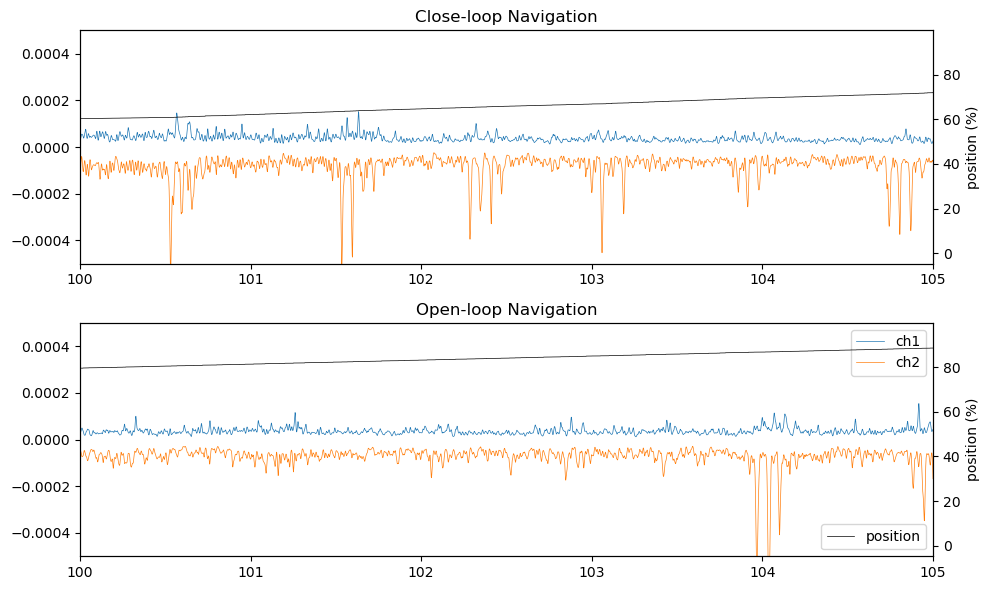

In [36]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))
ax = axes[0]
ax.plot(trace['behav_time'], trace['fltCh0'], lw=0.5)
ax.plot(trace['behav_time'], -trace['fltCh1'], lw=0.5)
axy = ax.twinx()
axy.plot(trace['behav_time'], trace['behav_pos'], color='k', lw=0.5)
axy.set_ylabel('position (%)')
ax.set_title('Close-loop Navigation')
ax.set_xlim(100, 105)
ax.set_ylim(-0.0005, 0.0005)


ax1 = axes[1]
ax1.plot(trace1['behav_time'], trace1['fltCh0'], lw=0.5, label='ch1')
ax1.plot(trace1['behav_time'], -trace1['fltCh1'], lw=0.5, label='ch2')
axy1 = ax1.twinx()
axy1.plot(trace1['behav_time'], trace1['behav_pos'], color='k', lw=0.5, label='position')
axy1.set_ylabel('position (%)')
ax1.set_title('Open-loop Navigation')
ax1.legend(loc='upper right')
axy1.legend(loc='lower right')
ax1.set_xlim(100, 105)
ax1.set_ylim(-0.0005, 0.0005)
plt.tight_layout()